---
title: "Decision trees"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: false
    code-summary: "Show the code"
---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             mean_squared_error, r2_score)



We’ll use the **Palmer Penguins** dataset (a friendlier drop-in replacement for Iris).  
Goal : predict whether a penguin is *Adelie* (`1`) or another species (`0`) with a shallow decision-tree and examine its performance.


In [ ]:
# load dataset
penguins = sns.load_dataset("penguins").dropna()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [6]:
# make binary target: 1 = adelie, 0 = other
penguins["is_adelie"] = (penguins["species"] == "Adelie").astype(int)
y = penguins["is_adelie"]
y

0      1
1      1
2      1
4      1
5      1
      ..
338    0
340    0
341    0
342    0
343    0
Name: is_adelie, Length: 333, dtype: int64

In [7]:
# one-hot encode remaining categoricals
X = penguins.drop(columns=["species", "is_adelie"])
print(penguins['island'].unique())
X = pd.get_dummies(X, drop_first=True)

X

['Torgersen' 'Biscoe' 'Dream']


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,0,1,1
1,39.5,17.4,186.0,3800.0,0,1,0
2,40.3,18.0,195.0,3250.0,0,1,0
4,36.7,19.3,193.0,3450.0,0,1,0
5,39.3,20.6,190.0,3650.0,0,1,1
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,0,0,0
340,46.8,14.3,215.0,4850.0,0,0,0
341,50.4,15.7,222.0,5750.0,0,0,1
342,45.2,14.8,212.0,5200.0,0,0,0


Note that originaly there are 3 islands but after applying one-hot encoding, we have binary for only 2 islands. because the third island is the reference category, we don't need to add a third column for it. If we have 0 for both islands, it means the penguin is from the third island.


In [20]:
# split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# fit a shallow tree (depth = 3 keeps it interpretable)
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)

# evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"test accuracy = {acc:.3f}")

test accuracy = 0.952


Text(0.5, 1.0, 'confusion matrix')

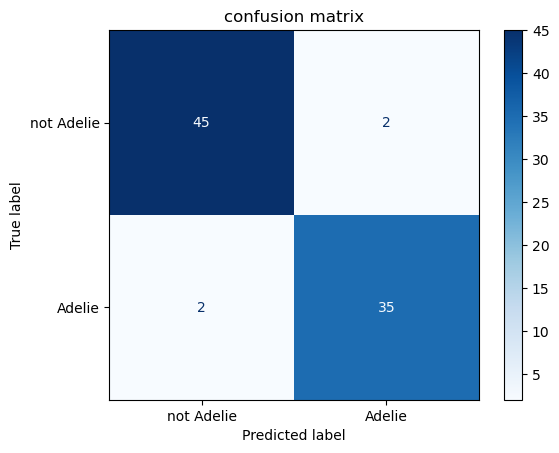

In [21]:
# confusion-matrix
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=["not Adelie", "Adelie"],
    cmap="Blues", ax=ax
)
ax.set_title("confusion matrix")

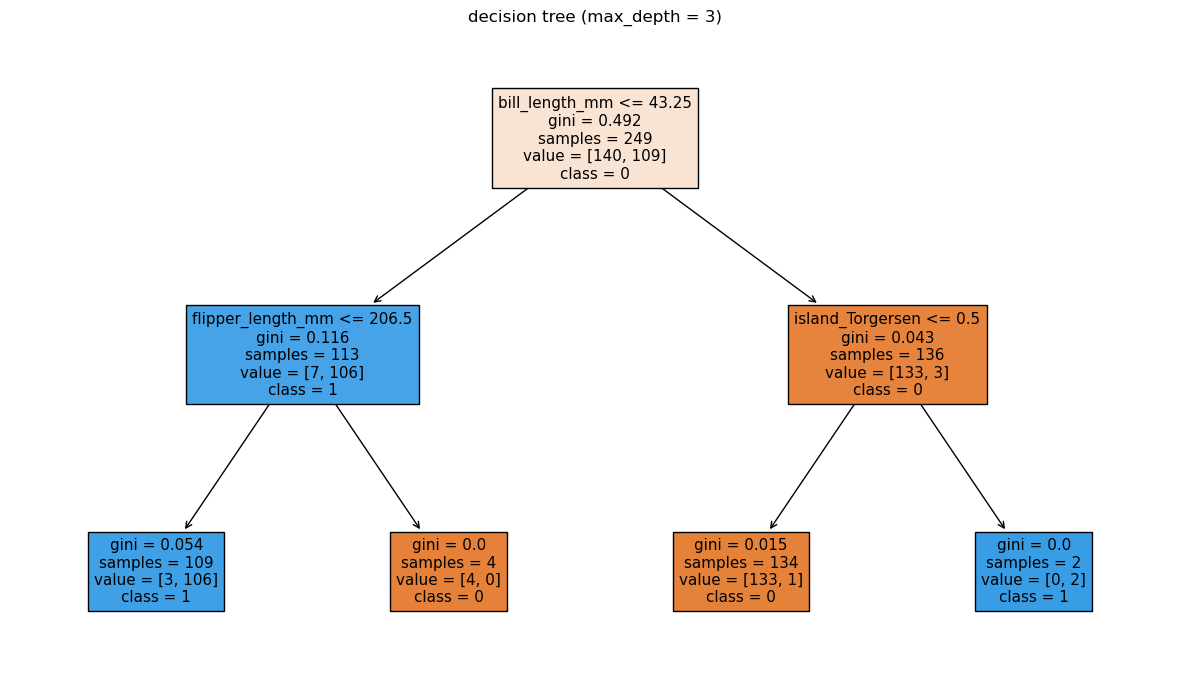

In [22]:
# tree visualisation
fig, ax = plt.subplots(figsize=(12, 7))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    impurity=True,
    ax=ax,
)
ax.set_title("decision tree (max_depth = 3)")
plt.tight_layout()




Text(0.5, 1.0, 'test-set predictions (red = Adelie)')

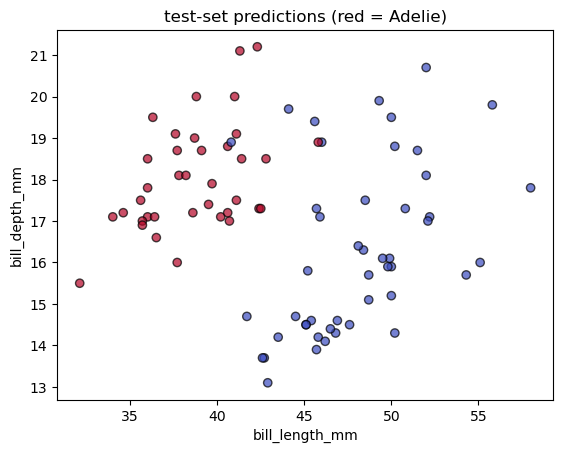

In [19]:
# simple 2-D scatter of test predictions for two bill metrics
fig, ax = plt.subplots()
scatter = ax.scatter(
    X_test["bill_length_mm"],
    X_test["bill_depth_mm"],
    c=y_pred,
    cmap="coolwarm",
    edgecolor="k",
    alpha=0.7,
)
ax.set_xlabel("bill_length_mm")
ax.set_ylabel("bill_depth_mm")
ax.set_title("test-set predictions (red = Adelie)")

## Regression example – predicting California house prices

We’ll switch to a **continuous** target: median house value (`MedHouseVal`, \$ × 100 000) from the built-in *California Housing* dataset.  
A single decision-tree regressor illustrates over-fitting risk and the effect of depth / leaf constraints.


In [27]:
# load dataset
from sklearn.datasets import fetch_california_housing

cal = fetch_california_housing(as_frame=True)
X = cal.data
y = cal.target

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [28]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

baseline tree → RMSE = 0.727, R² = 0.601
best params: {'max_depth': None, 'min_samples_leaf': 20}
cv RMSE: 0.6138382784769062
tuned tree → RMSE = 0.611, R² = 0.718


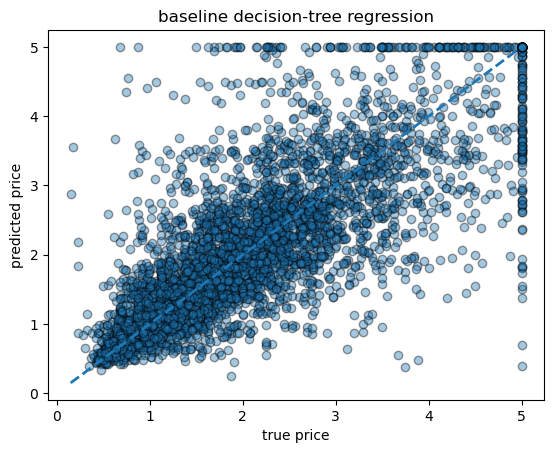

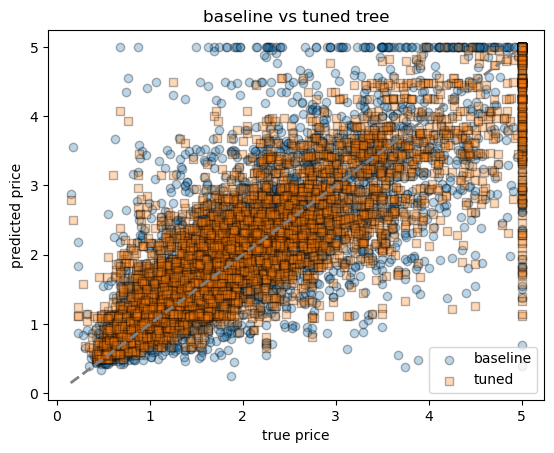

In [ ]:


# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# fit baseline tree (no depth limit)
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train, y_train)

# evaluate
y_pred = reg.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2   = r2_score(y_test, y_pred)
print(f"baseline tree → RMSE = {rmse:.3f}, R² = {r2:.3f}")

# scatter of true vs predicted
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.4, edgecolor="k")
ax.plot([y.min(), y.max()], [y.min(), y.max()], lw=2, ls="--")
ax.set_xlabel("true price")
ax.set_ylabel("predicted price")
ax.set_title("baseline decision-tree regression")

# ------------------------------------------------------------
# quick hyper-parameter sweep: depth & min_samples_leaf
param_grid = {
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 5, 20],
}
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("best params:", grid.best_params_)
print("cv RMSE:", -grid.best_score_)

# refit best tree on full training data and re-evaluate
best_reg = grid.best_estimator_
y_pred_best = best_reg.predict(X_test)
rmse_best = mean_squared_error(y_test, y_pred_best, squared=False)
r2_best   = r2_score(y_test, y_pred_best)
print(f"tuned tree → RMSE = {rmse_best:.3f}, R² = {r2_best:.3f}")

# compare baseline vs tuned in one plot
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.3, label="baseline", edgecolor="k")
ax.scatter(y_test, y_pred_best, alpha=0.3, label="tuned", marker="s", edgecolor="k")
ax.plot([y.min(), y.max()], [y.min(), y.max()], lw=2, ls="--", color="grey")
ax.set_xlabel("true price")
ax.set_ylabel("predicted price")
ax.set_title("baseline vs tuned tree")
ax.legend()


## Ensembles – Random-Forest & built-in feature importance


A forest averages many decorrelated trees to cut variance.  
We reuse the same training / test splits from Sections&nbsp;1 & 2 and compare:

* **Classification:** accuracy boost vs single tree  
* **Regression:** RMSE boost vs single tree  
* **Interpretability:** bar-plot of `feature_importances_`


single tree accuracy = 0.952
random-forest accuracy = 0.976


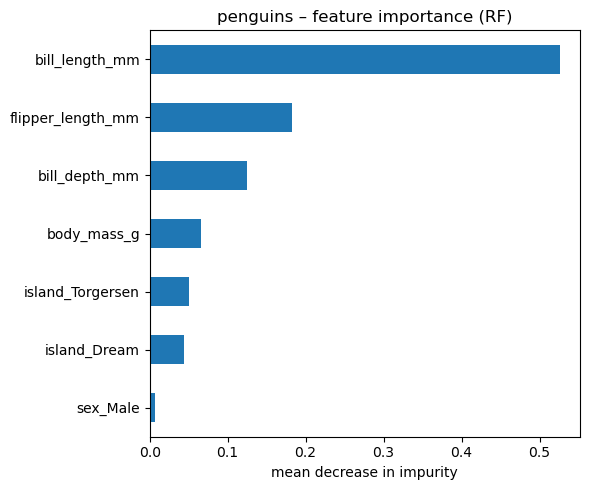

In [31]:
# ------------------------------------------------------------------
# classification – random-forest on penguins (kept separate from regression data)
# ------------------------------------------------------------------
penguins = sns.load_dataset("penguins").dropna()
penguins["is_adelie"] = (penguins["species"] == "Adelie").astype(int)

yc = penguins["is_adelie"]
Xc = pd.get_dummies(penguins.drop(columns=["species", "is_adelie"]), drop_first=True)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.25, stratify=yc, random_state=42
)

# baseline single tree for comparison
base_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
base_clf.fit(Xc_train, yc_train)
acc_base = accuracy_score(yc_test, base_clf.predict(Xc_test))

# random-forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(Xc_train, yc_train)

# accuracy
y_pred_rf = rf_clf.predict(Xc_test)
acc_rf = accuracy_score(yc_test, y_pred_rf)
print(f"single tree accuracy = {acc_base:.3f}")
print(f"random-forest accuracy = {acc_rf:.3f}")

# feature-importance plot
importances = (
    pd.Series(rf_clf.feature_importances_, index=Xc.columns)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(6, 5))
importances.tail(15).plot.barh(ax=ax)   # show top 15
ax.set_xlabel("mean decrease in impurity")
ax.set_title("penguins – feature importance (RF)")
plt.tight_layout()


random-forest RMSE = 0.502 (single tree was 0.611)
random-forest  R²  = 0.809 (single tree was 0.718)


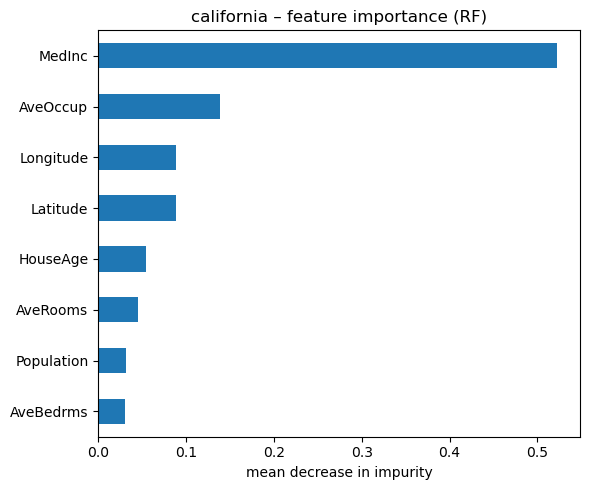

In [30]:
# ----- regression forest on california housing ------------------------------
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_reg.fit(X_train, y_train)

# test metrics
y_pred_rf = rf_reg.predict(X_test)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf   = r2_score(y_test, y_pred_rf)
print(f"random-forest RMSE = {rmse_rf:.3f} (single tree was {rmse_best:.3f})")
print(f"random-forest  R²  = {r2_rf:.3f} (single tree was {r2_best:.3f})")

# importance plot
importances_reg = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(6, 5))
importances_reg.tail(15).plot.barh(ax=ax)
ax.set_xlabel("mean decrease in impurity")
ax.set_title("california – feature importance (RF)")
plt.tight_layout()


### Permutation importance – a performance-based metric  

* **What it is** – After the model is trained, we **shuffle** one feature column at a time in the **held-out** data and measure how much the score (accuracy for classifiers, \(R^2\) for regressors) drops.  
* **Why it matters** –  
  * *Model-agnostic:* works for any fitted estimator, tree or otherwise.  
  * *Less biased:* doesn’t favour high-cardinality or continuous features the way impurity-based importance often does.  
* **Caveats** –  
  * Correlated predictors can share information → shuffling one may show little drop even if the group is crucial.  
  * Computationally heavier: needs many re-evaluations (`n_repeats`).  
* **Interpretation** – Larger mean drop ⇒ the model relied heavily on that feature. A near-zero (or negative) value ⇒ feature adds little unique information.


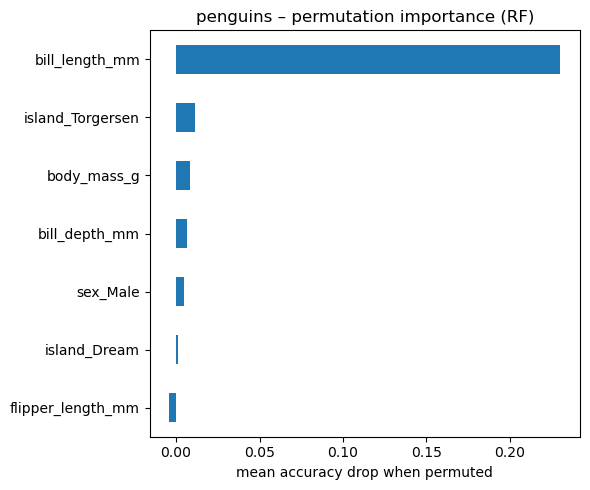

In [32]:
# permutation importance on the classification forest
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf_clf,
    Xc_test,
    yc_test,
    n_repeats=50,
    n_jobs=-1,
    random_state=42,
)

perm_imp = (
    pd.Series(result.importances_mean, index=Xc.columns)
      .sort_values()
)

# bar plot – compare with impurity importance
fig, ax = plt.subplots(figsize=(6, 5))
perm_imp.tail(15).plot.barh(ax=ax)
ax.set_xlabel("mean accuracy drop when permuted")
ax.set_title("penguins – permutation importance (RF)")
plt.tight_layout()


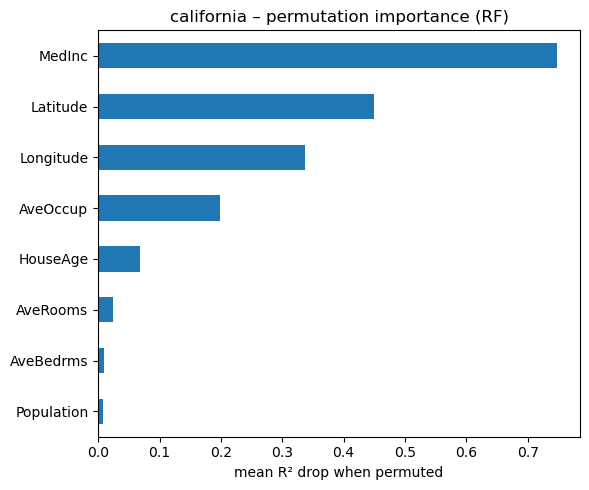

In [33]:
# permutation importance on the regression forest
from sklearn.inspection import permutation_importance

result_reg = permutation_importance(
    rf_reg,
    X_test,
    y_test,
    n_repeats=50,
    n_jobs=-1,
    random_state=42,
)

perm_imp_reg = (
    pd.Series(result_reg.importances_mean, index=X.columns)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(6, 5))
perm_imp_reg.tail(15).plot.barh(ax=ax)
ax.set_xlabel("mean R² drop when permuted")
ax.set_title("california – permutation importance (RF)")
plt.tight_layout()
